In [1]:
import numpy as np
import dpluspy
import moments 
import matplotlib.pyplot as plt 
import matplotlib 
import copy
import msprime
import demes 
import demesdraw
import pandas
from matplotlib.transforms import ScaledTranslation
from bokeh import palettes

In [2]:
"""
constants and rcparams for all figures
"""


matplotlib.rcParams["font.size"] = 10
matplotlib.rcParams['xtick.labelsize'] = 8
matplotlib.rcParams['ytick.labelsize'] = 8


# filenames
bherer_data = "statistics/main/bherer_stats.pkl"
zhou_data = "statistics/main/zhou_stats.pkl"
likelihood_tbl_fname = "models/main_models/likelihood_tbl.csv"


graph_color = "seagreen"


positions = {
    "Yoruba1": -1e4,
    "Stuttgart": 9e4,
    "Loschbour": 6e4,
    "UstIshim": 3e4,
    "Vindija": 1.2e5,
    "Chagyrskaya": 1.5e5, 
    "Altai": 1.8e5,
    "Denisova": 2.1e5,
    "Sup": 2.4e5,
    "MH": 3e4, 
    "WN": 1.35e5,
    "N": 1.55e5,
    "ND": 1.81e5,
    "Anc": 1.05e5
}
cs = palettes.Category20[20]
colors = {
    "Yoruba1": cs[0],
    "UstIshim": cs[2],
    "Loschbour": cs[4],
    "Stuttgart": cs[6],
    "Vindija": cs[8],
    "Chagyrskaya": cs[10],
    "Altai": cs[12],
    "Denisova": cs[14],
    "Sup": cs[1],
    "MH": cs[3],
    "WN": cs[5],
    "N": cs[7],
    "ND": cs[9],
    "Anc": cs[11],
}


# load a table of model likelihoods and recast it as a dictionary for easy access
ll_tbl = pandas.read_csv(likelihood_tbl_fname)
likelihoods = {model: ll for model, ll in zip(ll_tbl["model"], ll_tbl["ll"])}


def label_axs(fig, axs):
    # label mosaic subplots 
    for label, ax in axs.items():
        ax.text(0.0, 1.0, label, fontsize="medium", va="bottom", transform=(
            ax.transAxes + ScaledTranslation(-20/72, +0/72, fig.dpi_scale_trans)))
    return


def plot_tube(ax, mid, y, width, height):
    vertices = [
        [mid - width / 2, y + height], 
        [mid - width / 2, y], 
        [mid + width / 2, y + height], 
        [mid + width / 2, y]
    ]
    codes = [np.uint8(1), np.uint8(2), np.uint8(1), np.uint8(2)]
    tube = matplotlib.path.Path(vertices, codes)
    path_patch = matplotlib.patches.PathPatch(
        tube, capstyle="butt", fill=False, color=graph_color, zorder=1
    )
    ax.add_patch(path_patch)
    ax.fill_betweenx(
        [y + height, y],
        [mid - width / 2, mid - width / 2],
        [mid + width / 2, mid + width / 2],
        facecolor=graph_color,
        edgecolor=graph_color,
        alpha=0.5,
        zorder=1,
    )
    return


def make_size_legend(ax, center):
    plot_tube(ax, center, 1e4, 1e3, 2e3)
    plot_tube(ax, center, 1.7e4, 1e4, 2e3)
    plot_tube(ax, center, 2.4e4, 2e4, 2e3)
    ax.text(center + 1.1e4, 3.1e4, "$N_e$")
    ax.text(center + 1.8e4, 8e3, "$10^3$")
    ax.text(center + 1.8e4, 1.6e4, "$10^4$")
    ax.text(center + 1.8e4, 2.3e4, r"$2\times 10^4$")
    return


def label_axs(fig, axs):
    # label axs in mosaic subplots 
    for label, ax in axs.items():
        ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
            ax.transAxes + ScaledTranslation(-20/72, 4/72, fig.dpi_scale_trans)))
    return

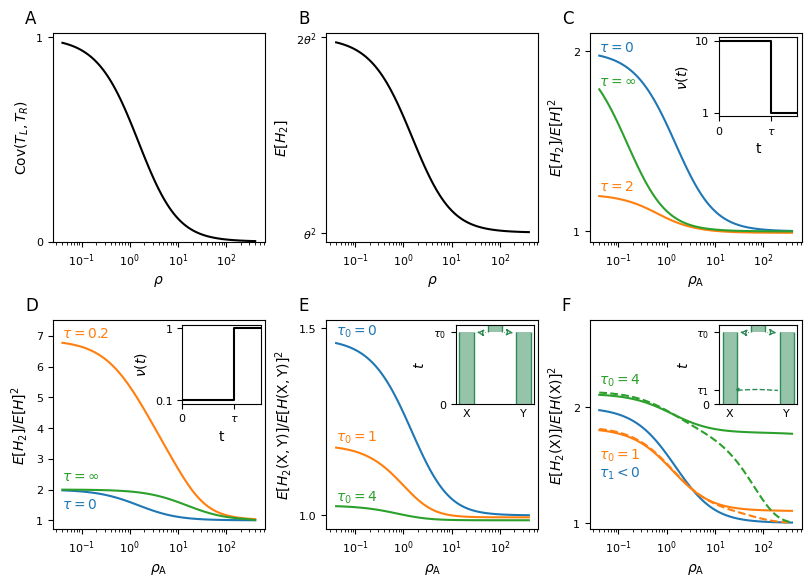

In [4]:
"""
create Figure 1, the main theory figure.
"""


inset_coords = [0.61, 0.60, 0.37, 0.38]
text_x = 4e-2
N = 1e4
u = 1e-8
theta = 4 * N * u
rs = np.logspace(np.log10(1e-6), np.log10(1e-2), 100)
rhos = 4 * N * rs


def make_covariance_plot(ax):
    # plot the genealogical covariance Cov(Tl, Tr) at equilibrium
    covs = (rhos + 18) / (rhos ** 2 + 13 * rhos + 18)
    ax.plot(rhos, covs, color="black")
    ax.set_xscale("log")
    ax.set_ylabel(r"$\operatorname{Cov}(T_L, T_R)$")
    ax.set_xlabel(r"$\rho$")
    ax.set_yticks([0, 1])
    ax.set_ylim(0, )
    return


def make_equil_expectation_plot(ax):
    yy = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp, color="black")
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2]$")
    ax.set_xlabel(r"$\rho$")
    ax.set_yticks([theta ** 2, 2 * theta ** 2], [r"$\theta^2$", r"$2\theta^2$"])
    return


def make_growth_plot(ax):
    inset = ax.inset_axes(inset_coords)
    inset.step([0, 1, 1.5], [10, 10, 1], color="black")
    inset.set_xticks([1, 0], [r"$\tau$", 0])
    inset.set_ylabel(r"$\nu(t)$")
    inset.set_xlabel("t")
    inset.set_xlim(0, 1.5)
    inset.set_yscale("log")
    inset.set_yticks([1, 10], [1, 10])
    inset.minorticks_off()

    yy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
    dp0 = yy0.H2(0)
    ax.plot(rhos, dp0 / yy0.H() ** 2, color="tab:blue")

    yy = moments.LD.Demographics1D.two_epoch([10, 2], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:orange")

    yy = moments.LD.Demographics1D.two_epoch([10, 100], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:green")

    ax.annotate(r"$\tau=0$", (text_x, 2), color="tab:blue")
    ax.annotate(r"$\tau=2$", (text_x, 1.23), color="tab:orange")
    ax.annotate(r"$\tau=\infty$", (text_x, 1.81), color="tab:green")
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2] / E[H]^2$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    ax.set_yticks([1, 2])
    ax.set_ylim(None, 2.1)
    return


def make_contraction_plot(ax):
    inset = ax.inset_axes(inset_coords)
    inset.step([0, 1, 1.5], [0.1, 0.1, 1], color="black", label="growth")
    inset.set_xticks([1, 0], [r"$\tau$", 0])
    inset.set_ylabel(r"$\nu(t)$")
    inset.set_xlabel("t")
    inset.set_xlim(0, 1.5)
    inset.set_yscale("log")
    inset.set_yticks([0.1, 1], [0.1, 1])
    inset.minorticks_off()

    yy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
    dp0 = yy0.H2(0)
    ax.plot(rhos, dp0 / yy0.H() ** 2, color="tab:blue")

    yy = moments.LD.Demographics1D.two_epoch([0.1, 0.2], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:orange")

    yy = moments.LD.Demographics1D.two_epoch([0.1, 5], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:green")

    ax.annotate(r"$\tau=0$", (text_x, 1.4), color="tab:blue")
    ax.annotate(r"$\tau=0.2$", (text_x, 6.95), color="tab:orange")
    ax.annotate(r"$\tau=\infty$", (text_x, 2.31), color="tab:green")

    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2] / E[H]^2$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    ax.set_ylim(None, 7.5)
    return


def make_island_plot(ax):
    inset = ax.inset_axes(inset_coords)
    builder = demes.Builder()
    builder.add_deme("A", epochs=[{"start_size": 1000, "end_time": 0}])
    builder.add_deme("B", epochs=[{"start_size": 1000, "end_time": 0}])
    builder.add_migration(rate=1e-4, demes=["A", "B"])
    graph = builder.resolve()
    demesdraw.tubes(graph, ax=inset, colours=graph_color, labels=None, 
                    num_lines_per_migration=4, positions={"A": 0, "B": 2e3})
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    inset.set_yticks([0])

    yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 0.5, 0.5], rho=rhos, theta=theta)
    ax.plot(rhos, yy.H2(0) / yy.H()[0] ** 2, color="tab:blue")
    ax.annotate("$M=1$", (text_x, 2.6), color="tab:blue")

    yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 2.5, 2.5], rho=rhos, theta=theta)
    ax.plot(rhos, yy.H2(0) / yy.H()[0] ** 2, color="tab:orange")
    ax.annotate("$M=5$", (text_x, 2.25), color="tab:orange")

    yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 50, 50], rho=rhos, theta=theta)
    ax.plot(rhos, yy.H2(0) / yy.H()[0] ** 2, color="tab:green")
    ax.annotate("$M=100$", (text_x, 1.6), color="tab:green")


    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2] / E[H]^2$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    ax.set_yticks([1, 2, 3])
    return


def get_isolation_model(T):
    builder = demes.Builder()
    builder.add_deme("A", epochs=[{"start_size": 1e4, "end_time": T}])
    builder.add_deme(
        "X", ancestors=["A"], epochs=[{"start_size": 1e4, "end_time": 0}])
    builder.add_deme(
        "Y", ancestors=["A"], epochs=[{"start_size": 1e4, "end_time": 0}])
    graph = builder.resolve()
    return graph


def make_isolation_plot(ax):
    inset = ax.inset_axes(inset_coords)
    graph = get_isolation_model(2e4)
    demesdraw.tubes(graph, ax=inset, labels="xticks", colours=graph_color, 
                    inf_ratio=0.10, positions={"A": 0, "X": -2e4, "Y": 2e4})
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    inset.set_yticks([0, 2e4], [0, r"$\tau_0$"])
    
    yy = moments.Demes.LD(
        get_isolation_model(1), sampled_demes=["X", "Y"], u=u, r=rs)
    dp = yy.H2(0, 1, phased=0)
    ax.plot(rhos, dp / yy.H()[1] ** 2, color="tab:blue")

    yy = moments.Demes.LD(
        get_isolation_model(2e4), sampled_demes=["X", "Y"], u=u, r=rs)
    dp = yy.H2(0, 1, phased=0)
    ax.plot(rhos, dp / yy.H()[1] ** 2, color="tab:orange")

    yy = moments.Demes.LD(
        get_isolation_model(8e4), sampled_demes=["X", "Y"], u=u, r=rs)
    dp = yy.H2(0, 1, phased=0)
    ax.plot(rhos, dp / yy.H()[1] ** 2, color="tab:green")

    ax.annotate(r"$\tau_0=0$", (text_x, 1.48), color="tab:blue")
    ax.annotate(r"$\tau_0=1$", (text_x, 1.2), color="tab:orange")
    ax.annotate(r"$\tau_0=4$", (text_x, 1.04), color="tab:green")

    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2(\text{X},\text{Y})] / E[H(\text{X}, \text{Y})]^2$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    ax.set_yticks([1, 1.5])
    ax.set_ylim(None, 1.52)
    return


def get_introgression_model(p, t0, t1):
    builder = demes.Builder()
    builder.add_deme("A", epochs=[{"start_size": 1e4, "end_time": t0}])
    builder.add_deme(
        "X", ancestors=["A"], epochs=[{"start_size": 1e4, "end_time": 0}])
    builder.add_deme(
        "Y", ancestors=["A"], epochs=[{"start_size": 1e4, "end_time": 0}])
    builder.add_pulse(sources=["Y"], dest="X", time=t1, proportions=[p])
    graph = builder.resolve()
    return graph


def make_introgression_model_plot(ax):
    graph = get_introgression_model(0.10, 500)
    demesdraw.tubes(graph, ax=ax, labels="xticks", fill=True, colours=graph_color)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel("$t$ (generations ago)")
    return


def make_introgression_plot(ax):
    inset = ax.inset_axes(inset_coords)
    graph = get_introgression_model(0.10, 2.5e4, 5e3)
    demesdraw.tubes(graph, ax=inset, labels="xticks", colours=graph_color, 
                    inf_ratio=0.10, positions={"A": 0, "X": -2e4, "Y": 2e4})
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    inset.set_yticks([0, 5000, 25000], [0, r"$\tau_1$", r"$\tau_0$"])
    
    yy = moments.Demes.LD(
        get_introgression_model(0.0, 2e4, 1), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:blue")

    yy = moments.Demes.LD(
        get_introgression_model(0.10, 2e4, 1), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:orange")
    yy = moments.Demes.LD(
        get_introgression_model(0.10, 2e4 + 500, 500), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, "--", color="tab:orange")

    yy = moments.Demes.LD(
        get_introgression_model(0.10, 8e4, 1), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:green")
    yy = moments.Demes.LD(
        get_introgression_model(0.10, 8e4 + 500, 500), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, "--", color="tab:green")

    ax.annotate(r"$\tau_1 < 0$", (text_x, 1.4), color="tab:blue")
    ax.annotate(r"$\tau_0=1$", (text_x, 1.55), color="tab:orange")
    ax.annotate(r"$\tau_0=4$", (text_x, 2.2), color="tab:green")
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_{2}(\text{X})] / E[H(\text{X})]^2$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    ax.set_yticks([1, 2])
    ax.set_ylim(None, 2.75)
    return


mosaic = "ABC;DEF"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 5.75), layout="constrained")
label_axs(fig, axs)
make_covariance_plot(axs["A"])
make_equil_expectation_plot(axs["B"])
make_growth_plot(axs["C"])
make_contraction_plot(axs["D"])
make_isolation_plot(axs["E"])
make_introgression_plot(axs["F"])
plt.savefig("figures/theory_overview.pdf")

In [3]:
"""
precomputation for Figure 2.
sets up three models with structured ancestry and finds panmictic models
with equivalent coalescence rate profiles.
"""


def get_structure_model(params):
    N0, N1, N2, T0, T1, p, m = params
    builder = demes.Builder()
    builder.add_deme("Anc", epochs=[{"start_size": N0, "end_time": T0}])
    builder.add_deme("X", ancestors=["Anc"], 
                     epochs=[{"start_size": N1, "end_time": T1}])
    builder.add_deme("Y", ancestors=["Anc"], 
                     epochs=[{"start_size": N2, "end_time": T1}])
    builder.add_deme("A", ancestors=["X", "Y"], proportions=[p, 1-p],
                     start_time=T1, 
                     epochs=[{"start_size": N0, "end_time": 0}])
    builder.add_migration(rate=m, demes=["X", "Y"])
    graph = builder.resolve()
    return graph


def compute_rate_trajectory(graph, ts, sample):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(ts, {sample: 2})
    return rates


def get_panmictic_model(ts, rates):
    Nes = 1 / (2 * np.array(rates))
    _ts = np.flip(ts)
    _Nes = np.flip(Nes)
    epochs = [
        {"start_size": Ne, "end_time": t} for Ne, t in zip(_Nes, _ts)
    ]
    builder = demes.Builder()
    builder.add_deme("A", epochs=epochs)
    graph = builder.resolve()
    return graph


ts = np.linspace(0, 2.5e4, 301)
structure_model0 = get_structure_model([1e4, 5e3, 5e3, 2.2e4, 2e3, 0.50, 0])
rates0 = compute_rate_trajectory(structure_model0, ts, "A")
panmictic_model0 = get_panmictic_model(ts, rates0)

structure_model1 = get_structure_model([1e4, 5e3, 5e3, 2.2e4, 2e3, 0.50, 2.5e-5])
rates1 = compute_rate_trajectory(structure_model1, ts, "A")
panmictic_model1 = get_panmictic_model(ts, rates1)

structure_model2 = get_structure_model([1e4, 5e3, 5e3, 2.2e4, 2e3, 0.50, 1.25e-4])
rates2 = compute_rate_trajectory(structure_model2, ts, "A")
panmictic_model2 = get_panmictic_model(ts, rates2)


rs = np.logspace(-6, -2, 31)
u = 1.3e-8
struc_yy0 = moments.Demes.LD(structure_model0, sampled_demes=["A"], r=rs, u=u)
struc_yy1 = moments.Demes.LD(structure_model1, sampled_demes=["A"], r=rs, u=u)
struc_yy2 = moments.Demes.LD(structure_model2, sampled_demes=["A"], r=rs, u=u)
pan_yy0 = moments.Demes.LD(panmictic_model0, sampled_demes=["A"], r=rs, u=u)
pan_yy1 = moments.Demes.LD(panmictic_model1, sampled_demes=["A"], r=rs, u=u)
pan_yy2 = moments.Demes.LD(panmictic_model2, sampled_demes=["A"], r=rs, u=u)

$f=0$ p=0.44
$f=0.05$ p=0.0
$f=0$ p=0.32
$f=0.01$ p=0.06


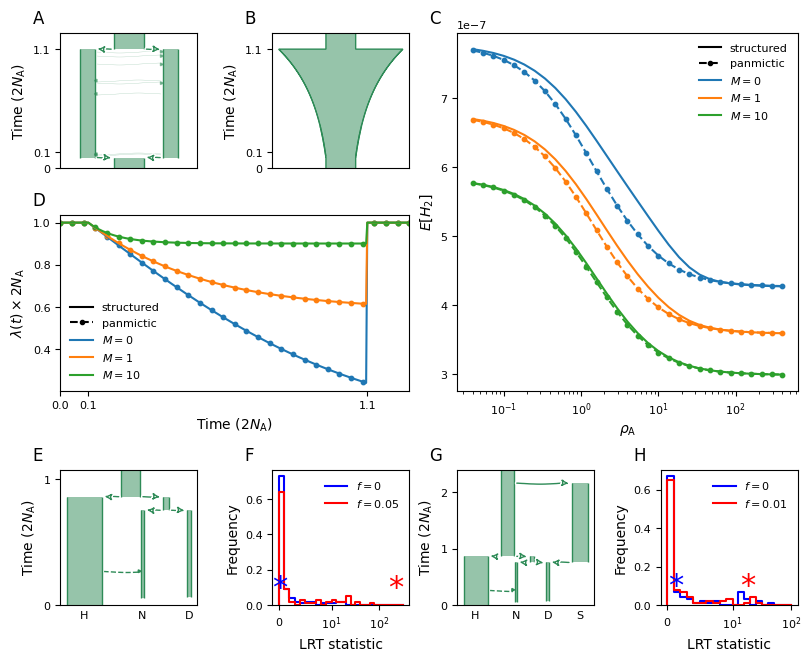

In [9]:
"""
create figure 2
"""


blrt_scores = pandas.read_csv("simulations/bootstrap_lrt_demo/blrt_demo_results.csv")


def make_coal_rate_plot(ax):
    xs = ts / 2e4
    ax.plot([], [], color="black", label="structured")
    ax.plot([], [], "--o", color="black", label="panmictic", markersize=3)
    ax.plot(xs, rates0 * 2e4, color="tab:blue", label="$M=0$")
    ax.plot(xs, rates1 * 2e4, color="tab:orange", label="$M=1$")
    ax.plot(xs, rates2 * 2e4, color="tab:green", label="$M=10$")

    _ts = np.linspace(0, 2.5e4, 31)
    pan_rates0 = compute_rate_trajectory(panmictic_model0, _ts, "A") * 2e4
    pan_rates1 = compute_rate_trajectory(panmictic_model1, _ts, "A") * 2e4
    pan_rates2 = compute_rate_trajectory(panmictic_model2, _ts, "A") * 2e4
    _xs = _ts / 2e4
    ax.scatter(_xs, pan_rates0, color="tab:blue", s=10)
    ax.scatter(_xs, pan_rates1, color="tab:orange", s=10)
    ax.scatter(_xs, pan_rates2, color="tab:green", s=10)
    ax.set_xlabel(r"Time ($2N_\text{A}$)")
    ax.set_ylabel(r"$\lambda(t) \times 2N_\text{A}$")
    ax.legend(framealpha=0, ncols=1)
    ax.set_xlim(0, )
    # ax.text(1.07, 0.35, "$M=0$", horizontalalignment="right", color="tab:blue", )
    # ax.text(1.07, 0.66, "$M=1$", horizontalalignment="right", color="tab:orange")
    # ax.text(1.07, 0.95, "$M=10$", horizontalalignment="right", color="tab:green")
    ax.set_xlim(0, xs[-1])
    ax.set_xticks([0, 0.1, 1.1])
    return


def plot_structure_model(ax):
    # plot demesdraw representation of the model
    plot_model = structure_model0
    demesdraw.tubes(
        plot_model, ax=ax, colours=graph_color, fill=True, labels=None,
        inf_ratio=0.4, positions={"Anc": 0, "X": -1.4e4, "Y": 1.4e4, "A": 0},
        num_lines_per_migration=4)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    ax.set_yticks([0, 5e3, 2.5e4], ["0", "$T_1$", "$T_0$"])
    ax.set_yticks([0, 3e3, 2.2e4], [0, 0.1, 1.1])
    ax.set_xlim(-2.3e4, 2.3e4)
    ax.set_ylim(0, 25000)
    return 


def plot_panmictic_model(ax):
    # plot demesdraw representation of the model
    plot_model = panmictic_model0
    demesdraw.tubes(
        plot_model, ax=ax, colours=graph_color, fill=True, labels=None,
        inf_ratio=0.4, num_lines_per_migration=4)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    ax.set_yticks([0, 5e3, 2.5e4], ["0", "$T_1$", "$T_0$"])
    ax.set_yticks([0, 3e3, 2.2e4], [0, 0.1, 1.1])
    ax.set_xlim(-2.3e4, 2.3e4)
    ax.set_ylim(0, 25000)
    return 


def make_curves_plot(ax):
    ax.plot([], [], color="black", label="structured")
    ax.plot([], [], "--o", color="black", label="panmictic", markersize=3)
    rhos = 4 * 1e4 * rs
    ax.plot(rhos, struc_yy0.H2(0), color="tab:blue", label="$M=0$")
    ax.plot(rhos, struc_yy1.H2(0), color="tab:orange", label="$M=1$")
    ax.plot(rhos, struc_yy2.H2(0), color="tab:green", label="$M=10$")

    ax.plot(rhos, pan_yy0.H2(0), "--", color="tab:blue")
    ax.plot(rhos, pan_yy1.H2(0), "--", color="tab:orange")
    ax.plot(rhos, pan_yy2.H2(0), "--", color="tab:green")
    ax.scatter(rhos, pan_yy0.H2(0), color="tab:blue", s=10)
    ax.scatter(rhos, pan_yy1.H2(0), color="tab:orange", s=10)
    ax.scatter(rhos, pan_yy2.H2(0), color="tab:green", s=10)
    ax.set_xscale("log")
    ax.set_ylabel(r"$E[H_2]$")
    ax.set_xlabel(r"$\rho_\text{A}$")
    ax.legend(framealpha=0)
    return


def freq_histogram(data, bins, ax, jitter=0, **kwargs):
    histogram = np.histogram(data, bins=bins)[0] / len(data)
    xs = np.concatenate(([1e-10], bins))
    xs += xs * jitter
    ys = np.concatenate(([0], histogram, [0]))
    ax.step(xs, ys, where="post", **kwargs)
    return


def make_hn_sim_model_plot(ax):
    graph_file = "simulations/bootstrap_lrt_demo/hn_alt_model.yaml"
    graph = demes.load(graph_file)
    demesdraw.tubes(graph, ax=ax, colours=graph_color, fill=True, labels=None,
        positions={"Anc": 0, "Yor": -4e4, "ND": 3e4, "Nea": 1e4, "Den": 5e4})
    ax.set_xticks([-4e4, 1e4, 5e4], ["H", "N", "D"])
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    times = np.array([0, 1,])
    _times = times * 2 * 1.6e4 * 29
    ax.set_yticks(_times, times)
    return


def make_hn_sim_blrt_plot(ax):
    models = ["hn_null_model_rep_5", "hn_model_5_rep_0"]
    colors = ["blue", "red"]
    labels = ["$f=0$", "$f=0.05$"]
    bins = list(np.linspace(0, 9, 10)) + list(np.logspace(1, 2.5, 16))
    for model, color, label in zip(models, colors, labels):
        sample_file = f"simulations/bootstrap_lrt_demo/results/{model}_samples.csv"
        samples = np.array(pandas.read_csv(sample_file)["score"])
        score = list(blrt_scores[blrt_scores["trial"] == f"{model}"]["score"])[0]
        freq_histogram(samples, bins, ax, color=color)
        ax.text(score, 0.1, "*", horizontalalignment="center", color=color,
                fontsize=22, verticalalignment="center")
        p_obs = np.count_nonzero(samples > score) / len(samples)
        ax.plot([], [], color=color, label=label)
        print(label, f"p={np.round(p_obs, 3)}")
    ax.legend(framealpha=0)
    ax.set_xscale("symlog", linthresh=10)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT statistic")
    ax.set_ylim(0, )
    return 


def make_sim_sd_model_plot(ax):    
    graph_file = "simulations/bootstrap_lrt_demo/sd_alt_model.yaml"
    graph = demes.load(graph_file)
    demesdraw.tubes(
        graph, ax=ax, colours=graph_color, fill=True, labels=None,inf_ratio=0.1,
        positions={"Anc": 0, "Yor": -4e4, "ND": 3e4, "Nea": 1e4, "Den": 5e4,
                   "Sup": 9e4})
    ax.set_xticks([-4e4, 1e4, 5e4, 9e4], ["H", "N", "D", "S"])
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel(r"Time ($2N_\text{A}$)")
    times = np.array([0, 1, 2])
    _times = times * 2 * 1.6e4 * 29
    ax.set_yticks(_times, times)
    return 


def make_sd_sim_blrt_plot(ax):
    models = ["sd_null_model_rep_3", "sd_model_1_rep_1"]
    colors = ["blue", "red"]
    labels = ["$f=0$", "$f=0.01$"]
    bins = list(np.linspace(0, 9, 10)) + list(np.logspace(1, 2, 11))
    for model, color, label in zip(models, colors, labels):
        sample_file = f"simulations/bootstrap_lrt_demo/results/{model}_samples.csv"
        samples = np.array(pandas.read_csv(sample_file)["score"])
        score = list(blrt_scores[blrt_scores["trial"] == f"{model}"]["score"])[0]
        freq_histogram(samples, bins, ax, color=color)
        ax.text(score, 0.1, "*", horizontalalignment="center", color=color,
                fontsize=22, verticalalignment="center")
        p_obs = np.count_nonzero(samples > score) / len(samples)
        ax.plot([], [], color=color, label=label)
        print(label, f"p={np.round(p_obs, 3)}")
    ax.legend(framealpha=0)
    ax.set_xscale("symlog", linthresh=10)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT statistic")
    ax.set_ylim(0, )
    return


mosaic = "ABCC;DDCC;EFGH"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6.5), layout="constrained",
                              height_ratios=[1, 1.3, 1])
label_axs(fig, axs)
plot_structure_model(axs["A"])
plot_panmictic_model(axs["B"])
make_curves_plot(axs["C"])
make_coal_rate_plot(axs["D"])
make_hn_sim_model_plot(axs["E"])
make_hn_sim_blrt_plot(axs["F"])
make_sim_sd_model_plot(axs["G"])
make_sd_sim_blrt_plot(axs["H"])
plt.savefig("figures/simulation_overview.pdf")

In [11]:
"""
load data for human-neanderthal introgression model plot
"""


hum_nea_null_graph = "models/main_models/bherer_amh_nea_no_pulse.yaml"
hum_nea_alt_graph = "models/main_models/bherer_amh_nea_two_pulse.yaml"
hum_nea_data = dpluspy.inference.load_stats(
    bherer_data, graph=hum_nea_null_graph, return_dict=1)
bins = hum_nea_data["bins"]
hum_nea_pop_ids = hum_nea_data["pop_ids"]
hn_model0 = dpluspy.inference.compute_bin_stats(
    hum_nea_null_graph, bins=bins, u=1.3e-8, sampled_demes=hum_nea_pop_ids)
hn_model1 = dpluspy.inference.compute_bin_stats(
    hum_nea_alt_graph, bins=bins, u=1.3e-8, sampled_demes=hum_nea_pop_ids)

bher_scores_test_1 = pandas.read_csv("models/blrt/bherer_amh_n_pulse.csv")["score"]
zhou_scores_test_1 = pandas.read_csv("models/blrt/zhou_amh_n_pulse.csv")["score"]
bher_scores_test_2 = pandas.read_csv("models/blrt/bherer_amh_wn_pulse.csv")["score"]
zhou_scores_test_2 = pandas.read_csv("models/blrt/zhou_amh_wn_pulse.csv")["score"]


def plot_amh_nea_curve_panel(ax, stat, label):
    dpluspy.plotting.plot_data_on_ax(
        ax, hum_nea_data, stat, "data",  color="tab:grey", linestyle="--", )
    dpluspy.plotting.plot_model_on_ax(
        ax, hn_model0, bins, stat, "null", color="tab:blue")
    dpluspy.plotting.plot_model_on_ax(
        ax, hn_model1, bins, stat, "alt", color="tab:orange")
    ax.set_title(label, y=0.8, fontsize="small")
    ax.legend(framealpha=0, fontsize="x-small", loc=(0.55, 0.4))
    ax.set_ylabel("$H_2$")
    ax.set_xlabel("$r$")
    return

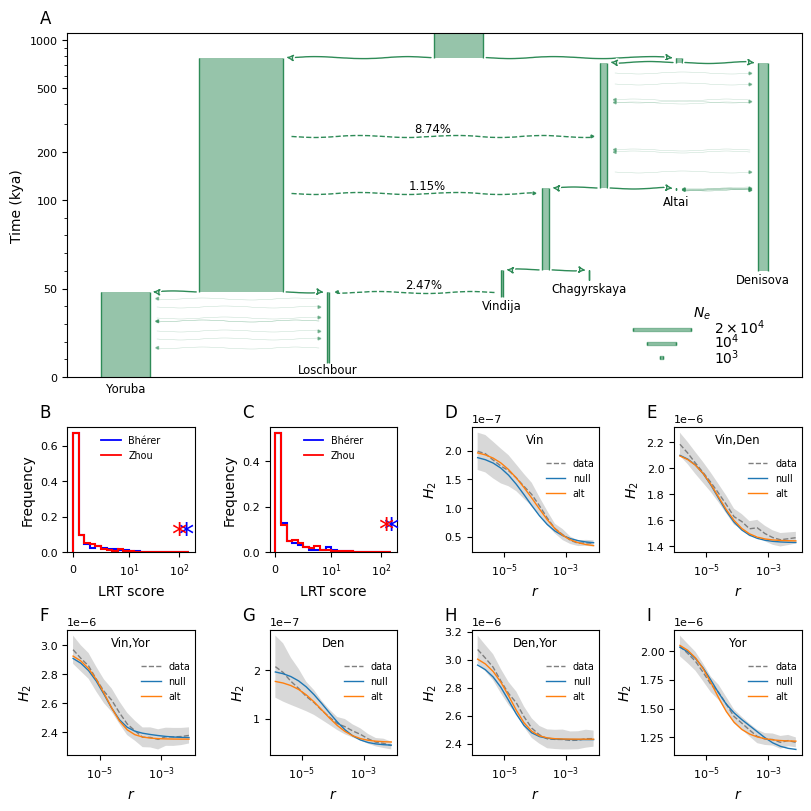

In [49]:
def plot_hn_model(ax):
    fname = hum_nea_alt_graph
    graph = demes.load(fname)
    pops = [
        "Yoruba1",
        "Loschbour",
        "Vindija",
        "Chagyrskaya", 
        "Altai",
        "Denisova",
        "MH", 
        "WN",
        "N",
        "ND",
        "Anc"
    ]
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        inf_ratio=0.30,
        log_time=False,
        positions={x: positions[x] for x in pops},
        colours=graph_color,
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    label_positions = {
        "Vindija": (positions["Vindija"], 3.8e4),
        "Chagyrskaya": (positions["Chagyrskaya"], 4.8e4),
        "Altai": (positions["Altai"], 9.7e4),
        "Denisova": (positions["Denisova"], 5.3e4),
        "Loschbour": (positions["Loschbour"], 2e3),
    }
    for label, (x, y) in label_positions.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")
    pulse_annotations = {
        "2.47%": (9.3e4, 5e4),
        "1.15%": (9.4e4, 1.16e5),
        "8.74%": (9.6e4, 2.65e5)
    }
    for label, (x, y) in pulse_annotations.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")
    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"], fontsize="small")
    ax.set_yscale("symlog", linthresh=1e5)
    ax.set_ylabel("Time (kya)")
    yticks = [0, 5e4, 1e5, 2e5, 5e5, 1e6]
    ax.set_yticks(yticks, np.array(yticks).astype(np.int64) // 1000)
    yticks = np.concatenate(
        (np.arange(0, 100000, 10000), np.arange(200000, 1000000, 100000)))
    ax.set_yticks(yticks, minor=True)
    return


def plot_blrt_test1(ax):
    # compute focal LRT scores
    ll_b0 = likelihoods["bherer_amh_nea_no_pulse"]
    ll_b1 = likelihoods["bherer_amh_nea_one_pulse"]
    ll_z0 = likelihoods["zhou_amh_nea_no_pulse"]
    ll_z1 = likelihoods["zhou_amh_nea_one_pulse"]
    bherer_score = 2 * (ll_b1 - ll_b0)
    zhou_score = 2 * (ll_z1 - ll_z0)
    bins = list(np.linspace(0, 9, 10)) + list(np.logspace(1, 2.2, 12))
    ax.set_xscale("symlog", linthresh=10)
    ax.hist(bher_scores_test_1, bins=bins, histtype="step", lw=1.5, density=1, 
        color="blue")
    ax.hist(zhou_scores_test_1, bins=bins, histtype="step", lw=1.5, density=1, 
        color="red")
    ax.text(bherer_score, 0.1, "*", horizontalalignment="center", 
        color="blue", fontsize=22, verticalalignment="center")
    ax.text(zhou_score, 0.1, "*", horizontalalignment="center", 
        color="red", fontsize=22, verticalalignment="center")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT score")
    ax.plot([], [], color="blue", lw=1.3, label="Bhérer")
    ax.plot([], [], color="red", lw=1.3, label="Zhou")
    ax.legend(framealpha=0, loc="upper center", fontsize="x-small")


def plot_blrt_test2(ax):
    # compute focal LRT scores
    ll_b1 = likelihoods["bherer_amh_nea_one_pulse"]
    ll_b2 = likelihoods["bherer_amh_nea_two_pulse"]
    ll_z1 = likelihoods["zhou_amh_nea_one_pulse"]
    ll_z2 = likelihoods["zhou_amh_nea_two_pulse"]
    bherer_score = 2 * (ll_b2 - ll_b1)
    zhou_score = 2 * (ll_z2 - ll_z1)
    bins = list(np.linspace(0, 9, 10)) + list(np.logspace(1, 2.2, 12))
    ax.set_xscale("symlog", linthresh=10)
    ax.hist(bher_scores_test_2, bins=bins, histtype="step", lw=1.5, density=1, 
        color="blue")
    ax.hist(zhou_scores_test_2, bins=bins, histtype="step", lw=1.5, density=1, 
        color="red")
    ax.text(bherer_score, 0.1, "*", horizontalalignment="center", 
        color="blue", fontsize=22, verticalalignment="center")
    ax.text(zhou_score, 0.1, "*", horizontalalignment="center", 
        color="red", fontsize=22, verticalalignment="center")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT score")
    ax.plot([], [], color="blue", lw=1.3, label="Bhérer")
    ax.plot([], [], color="red", lw=1.3, label="Zhou")
    ax.legend(framealpha=0, loc="upper center", fontsize="x-small")


def make_size_legend(ax, center):
    plot_tube(ax, center, 1e4, 1e3, 2e3)
    plot_tube(ax, center, 1.8e4, 1e4, 2e3)
    plot_tube(ax, center, 2.6e4, 2e4, 2e3)
    ax.text(center + 1.1e4, 3.4e4, "$N_e$")
    ax.text(center + 1.8e4, 8e3, "$10^3$")
    ax.text(center + 1.8e4, 1.7e4, "$10^4$")
    ax.text(center + 1.8e4, 2.5e4, r"$2\times 10^4$")
    return


mosaic = "AAAA;BCDE;FGHI"
fig, axs = plt.subplot_mosaic(
    mosaic, figsize=(8, 8), layout="constrained", height_ratios=[2.75, 1, 1])
label_axs(fig, axs)
plot_hn_model(axs["A"])
make_size_legend(axs["A"], 1.75e5)
plot_blrt_test1(axs["B"])
plot_blrt_test2(axs["C"])
plot_amh_nea_curve_panel(axs["D"], "D+_1_1", "Vin")
plot_amh_nea_curve_panel(axs["E"], "D+_1_3", "Vin,Den")
plot_amh_nea_curve_panel(axs["F"], "D+_1_5", "Vin,Yor")
plot_amh_nea_curve_panel(axs["G"], "D+_3_3", "Den")
plot_amh_nea_curve_panel(axs["H"], "D+_3_5", "Den,Yor")
plot_amh_nea_curve_panel(axs["I"], "D+_5_5", "Yor")
plt.savefig("figures/amh_neanderthal_models.pdf")

In [115]:
"""
load data for superarchaic introgression model plot
"""


sup_den_null_graph = demes.load("models/main_models/bherer_sup_den_no_pulse.yaml")
sup_den_alt_graph = demes.load("models/main_models/bherer_sup_den.yaml")

sup_den_data = dpluspy.inference.load_stats(bherer_data, graph=sup_den_null_graph, return_dict=1)
bins = sup_den_data["bins"]
pop_ids = sup_den_data["pop_ids"]
sup_den_null_model = dpluspy.inference.compute_bin_stats(
    sup_den_null_graph, bins=bins, u=1.3e-8, sampled_demes=pop_ids)
sup_den_alt_model = dpluspy.inference.compute_bin_stats(
    sup_den_alt_graph, bins=bins, u=1.3e-8, sampled_demes=pop_ids)

bher_scores_test_1 = pandas.read_csv("models/blrt/bherer_sup_den_pulse.csv")["score"]
zhou_scores_test_1 = pandas.read_csv("models/blrt/zhou_sup_den_pulse.csv")["score"]
bher_scores_test_2 = pandas.read_csv("models/blrt/bherer_sup_den_pulse_without_amh_nea.csv")["score"]
zhou_scores_test_2 = pandas.read_csv("models/blrt/zhou_sup_den_pulse_without_amh_nea.csv")["score"]


def plot_sup_den_curve_panel(ax, stat, label):
    dpluspy.plotting.plot_data_on_ax(
        ax, sup_den_data, stat, "data",  color="tab:grey", linestyle="--", )
    dpluspy.plotting.plot_model_on_ax(
        ax, sup_den_null_model, bins, stat, "null", color="tab:blue")
    dpluspy.plotting.plot_model_on_ax(
        ax, sup_den_alt_model, bins, stat, "alt", color="tab:orange")
    ax.set_title(label, y=0.8, fontsize="small")
    ax.legend(framealpha=0, fontsize="x-small", loc=(0.55, 0.4))
    ax.set_ylabel("$H_2$")
    ax.set_xlabel("$r$")
    return

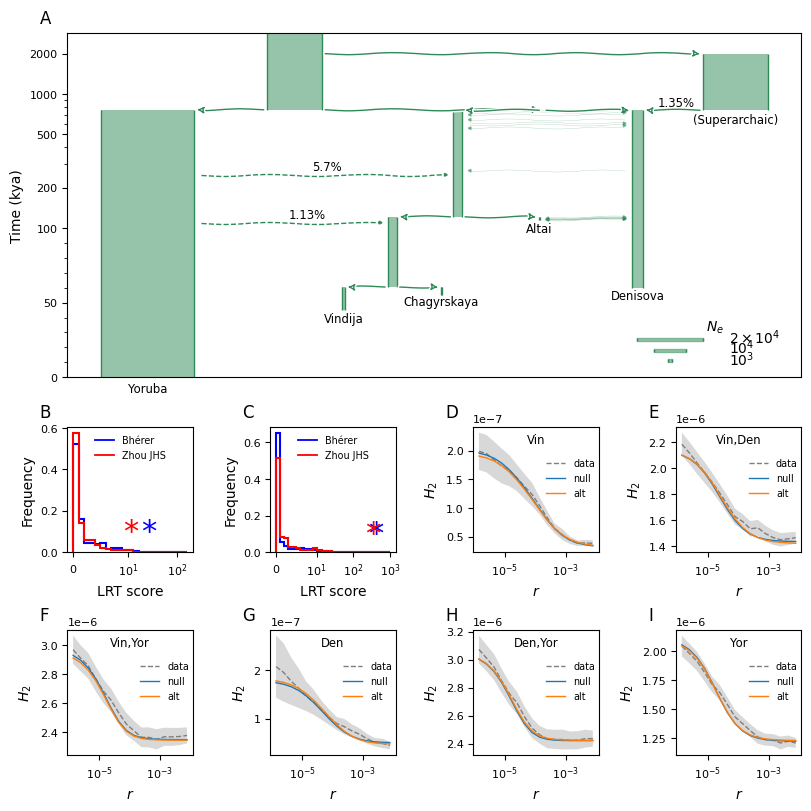

In [116]:
"""
plot models of supearchaic introgression
"""


def plot_sd_model(ax):
    pops = [
        "Anc",
        "Sup",
        "Yoruba1",
        "WN",
        "N", 
        "ND",
        "Vindija",
        "Chagyrskaya",
        "Altai",
        "Denisova"
    ]
    global positions
    positions = copy.copy(positions)
    positions["Yoruba1"] = 6e4
    demesdraw.tubes(
        sup_den_alt_graph,
        ax=ax,
        labels=None,
        inf_ratio=0.30,
        positions={x: positions[x] for x in pops},
        colours=graph_color,
        num_lines_per_migration=4,
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    # annotate demes
    label_positions = {
        "Vindija": (positions["Vindija"], 3.7e4),
        "Chagyrskaya": (positions["Chagyrskaya"], 4.8e4),
        "Altai": (positions["Altai"], 9.7e4),
        "Denisova": (positions["Denisova"], 5.2e4),
        "(Superarchaic)": (positions["Sup"], 6.1e5),
    }
    for label, (x, y) in label_positions.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")
    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"], fontsize="small")
    pulse_annotations = {
        "1.13%": (1.09e5, 1.18e5),
        "5.7%": (1.15e5, 2.68e5),
        "1.35%": (2.22e5, 8.05e5),
    }
    for label, (x, y) in pulse_annotations.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")
    ax.set_yscale("symlog", linthresh=1e5)
    ax.set_ylabel("Time (kya)")
    yticks = [0, 5e4, 1e5, 2e5, 5e5, 1e6, 2e6]
    ax.set_yticks(yticks, np.array(yticks).astype(np.int64) // 1000)
    yticks = np.concatenate(
        (np.arange(0, 100000, 10000), np.arange(200000, 1000000, 100000)))
    ax.set_yticks(yticks, minor=True)
    return


def plot_blrt_test1(ax):
    # compute focal LRT scores
    ll_b0 = likelihoods["bherer_sup_den_no_pulse"]
    ll_b1 = likelihoods["bherer_sup_den"]
    ll_z0 = likelihoods["zhou_sup_den_no_pulse"]
    ll_z1 = likelihoods["zhou_sup_den"]
    bherer_score = 2 * (ll_b1 - ll_b0)
    zhou_score = 2 * (ll_z1 - ll_z0)
    ax.text(bherer_score, 0.1, "*", horizontalalignment="center", 
        color="blue", fontsize=22, verticalalignment="center")
    ax.text(zhou_score, 0.1, "*", horizontalalignment="center", 
        color="red", fontsize=22, verticalalignment="center")
    bins = list(np.linspace(0, 9, 10)) + list(np.logspace(1, 2.2, 12))
    ax.set_xscale("symlog", linthresh=10)
    ax.hist(bher_scores_test_1, bins=bins, histtype="step", lw=1.5, density=1, 
        color="blue")
    ax.hist(zhou_scores_test_1, bins=bins, histtype="step", lw=1.5, density=1, 
        color="red")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT score")
    ax.plot([], [], color="blue", lw=1.3, label="Bhérer")
    ax.plot([], [], color="red", lw=1.3, label="Zhou JHS")
    ax.legend(framealpha=0, loc="upper center", fontsize="x-small")


def plot_blrt_test2(ax):
    # compute focal LRT scores
    ll_b0 = likelihoods["bherer_sup_den_without_amh_nea_no_pulse"]
    ll_b1 = likelihoods["bherer_sup_den_without_amh_nea"]
    ll_z0 = likelihoods["zhou_sup_den_without_amh_nea_no_pulse"]
    ll_z1 = likelihoods["zhou_sup_den_without_amh_nea"]
    bherer_score = 2 * (ll_b1 - ll_b0)
    zhou_score = 2 * (ll_z1 - ll_z0)
    ax.text(bherer_score, 0.1, "*", horizontalalignment="center", 
        color="blue", fontsize=22, verticalalignment="center")
    ax.text(zhou_score, 0.1, "*", horizontalalignment="center", 
        color="red", fontsize=22, verticalalignment="center")
    bins = list(np.linspace(0, 9, 10)) + list(np.logspace(1, 3, 15))
    ax.set_xscale("symlog", linthresh=10)
    ax.hist(
        bher_scores_test_2, bins=bins, histtype="step", lw=1.5, density=1, color="blue")
    ax.hist(
        zhou_scores_test_2, bins=bins, histtype="step", lw=1.5, density=1, color="red")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT score")
    ax.plot([], [], color="blue", lw=1.3, label="Bhérer")
    ax.plot([], [], color="red", lw=1.3, label="Zhou JHS")
    ax.legend(framealpha=0, loc="upper center", fontsize="x-small")


mosaic = "AAAA;BCDE;FGHI"
fig, axs = plt.subplot_mosaic(
    mosaic, figsize=(8, 8), layout="constrained", height_ratios=[2.75, 1, 1])
label_axs(fig, axs)
plot_sd_model(axs["A"])
make_size_legend(axs["A"], 2.2e5)
plot_blrt_test1(axs["B"])
plot_blrt_test2(axs["C"])
plot_sup_den_curve_panel(axs["D"], "D+_1_1", "Vin")
plot_sup_den_curve_panel(axs["E"], "D+_1_3", "Vin,Den")
plot_sup_den_curve_panel(axs["F"], "D+_1_4", "Vin,Yor")
plot_sup_den_curve_panel(axs["G"], "D+_3_3", "Den")
plot_sup_den_curve_panel(axs["H"], "D+_3_4", "Den,Yor")
plot_sup_den_curve_panel(axs["I"], "D+_4_4", "Yor")
plt.savefig("figures/superarchaic_models.pdf")

In [6]:
"""
load files for modern human model plot
"""


mh_graph_0 = "models/main_models/bherer_los_stu_isolation.yaml"
mh_graph_m = "models/main_models/bherer_los_stu_migration.yaml"
mh_graph_p = "models/main_models/bherer_los_stu_admixture.yaml"

mh_data = dpluspy.inference.load_stats(bherer_data, graph=mh_graph_0, return_dict=1)
bins = mh_data["bins"]
pop_ids = mh_data["pop_ids"]
mh_model_0 = dpluspy.inference.compute_bin_stats(
    mh_graph_0, bins=bins, u=1.3e-8, sampled_demes=pop_ids)
mh_model_m = dpluspy.inference.compute_bin_stats(
    mh_graph_m, bins=bins, u=1.3e-8, sampled_demes=pop_ids)
mh_model_p = dpluspy.inference.compute_bin_stats(
    mh_graph_p, bins=bins, u=1.3e-8, sampled_demes=pop_ids)

bher_scores = pandas.read_csv("models/blrt/bherer_los_stu_pulse.csv")["score"]
zhou_scores = pandas.read_csv("models/blrt/zhou_los_stu_pulse.csv")["score"]


def plot_curve_panel(ax, stat, label):
    dpluspy.plotting.plot_data_on_ax(
        ax, mh_data, stat, "data",  color="tab:grey", linestyle="--", )
    dpluspy.plotting.plot_model_on_ax(
        ax, mh_model_0, bins, stat, "null", color="tab:blue")
    dpluspy.plotting.plot_model_on_ax(
        ax, mh_model_m, bins, stat, "mig", color="tab:orange")
    dpluspy.plotting.plot_model_on_ax(
        ax, mh_model_p, bins, stat, "pulse", color="tab:green")
    ax.set_title(label, y=0.8, fontsize="small")
    ax.legend(framealpha=0, fontsize="x-small", loc=(0.52, 0.35))
    ax.set_ylabel("$H_2$")
    ax.set_xlabel("$r$")
    return

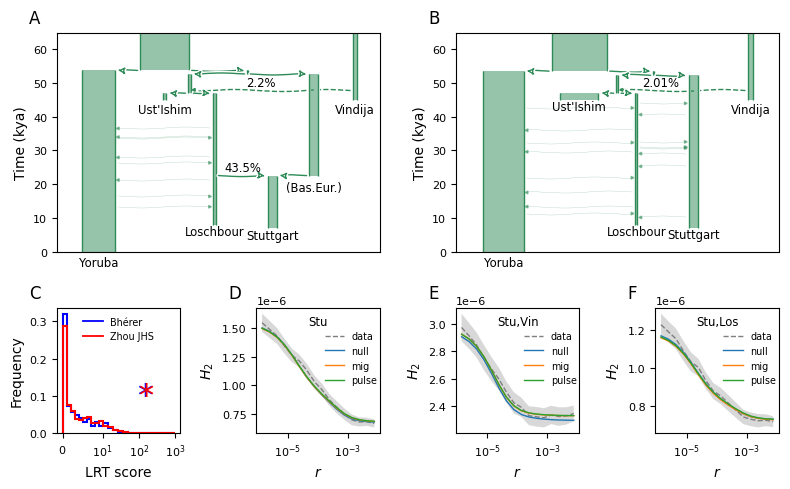

In [7]:
"""
plot amh contact models
"""


def plot_mig_model(ax):
    fname = "models/main_models/bherer_los_stu_migration_edited.yaml"
    graph = demes.load(fname)
    pops = [
        "Anc",
        "MH",
        "Yoruba1",
        "Loschbour",
        "Stuttgart", 
        "Vindija",
        "UstIshim",
        "OOA0",
        "OOA1",
    ]
    positions = {
        "Yoruba1": -1e4,
        "Stuttgart": 9e4,
        "Loschbour": 6e4,
        "UstIshim": 3e4,
        "Vindija": 1.2e5,
        "Chagyrskaya": 1.5e5, 
        "Altai": 1.8e5,
        "Denisova": 2.1e5,
        "Sup": 2.4e5,
        "MH": 3e4, 
        "WN": 1.35e5,
        "N": 1.55e5,
        "ND": 1.81e5,
        "Anc": 1.05e5,
        "OOA0": 6.9e4,
        "OOA1": 5e4,
        "BE": 1e5
    }

    _positions = {x: positions[x] for x in pops}
    # map deme names to desired labels
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        positions=_positions,
        colours=graph_color,
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    yticks = [0, 10, 20, 30, 40, 50, 60]
    ax.set_yticks(np.array(yticks) * 1e3, yticks)
    ax.set_ylabel("Time (kya)")
    ax.set_xticks([_positions["Yoruba1"]], ["Yoruba"], fontsize="small")
    label_positions = {
        "Vindija": (_positions["Vindija"], 4.1e4),
        "Loschbour": (_positions["Loschbour"], 5e3),
        "Stuttgart": (_positions["Stuttgart"], 4e3),
        "Ust'Ishim":  (_positions["UstIshim"], 4.2e4)
    }
    for label, (x, y) in label_positions.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")

    pulse_annotations = {
        "2.01%": (7.3e4, 4.92e4),
    }
    for label, (x, y) in pulse_annotations.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")
    ax.set_ylim(0, 6.5e4)
    ax.set_xlim(-3.5e4, 1.35e5)
    return


def plot_pulse_model(ax):
    fname = "models/main_models/bherer_los_stu_admixture_edited.yaml"
    graph = demes.load(fname)
    pops = [
        "Anc",
        "MH",
        "Yoruba1",
        "Loschbour",
        "Stuttgart", 
        "Vindija",
        "UstIshim",
        "OOA0",
        "OOA1",
        "BE"
    ]
    positions = {
        "Yoruba1": -1e4,
        "Stuttgart": 9.5e4,
        "Loschbour": 6e4,
        "UstIshim": 3e4,
        "Vindija": 1.45e5,
        "Chagyrskaya": 1.5e5, 
        "Altai": 1.8e5,
        "Denisova": 2.1e5,
        "Sup": 2.4e5,
        "MH": 3e4, 
        "WN": 1.35e5,
        "N": 1.55e5,
        "ND": 1.81e5,
        "Anc": 1.05e5,
        "OOA0": 8e4,
        "OOA1": 4.5e4,
        "BE": 1.2e5
    }

    _positions = {x: positions[x] for x in pops}
    # map deme names to desired labels
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        positions=_positions,
        colours=graph_color,
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    yticks = [0, 10, 20, 30, 40, 50, 60]
    ax.set_yticks(np.array(yticks) * 1e3, yticks)
    ax.set_ylabel("Time (kya)")

    ax.set_xticks([_positions["Yoruba1"]], ["Yoruba"], fontsize="small")
    label_positions = {
        "Vindija": (_positions["Vindija"], 4.1e4),
        "Loschbour": (_positions["Loschbour"], 4.9e3),
        "Stuttgart": (_positions["Stuttgart"], 3.7e3),
        "Ust'Ishim":  (_positions["UstIshim"], 4.1e4),
        "(Bas.Eur.)":  (_positions["BE"], 1.8e4)
    }
    for label, (x, y) in label_positions.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")
    
    pulse_annotations = {
        "2.2%": (8.8e4, 4.92e4),
        "43.5%": (7.7e4, 2.4e4),
    }
    for label, (x, y) in pulse_annotations.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")

    ax.set_ylim(0, 6.5e4)
    ax.set_xlim(-3.5e4, 1.6e5)
    return


def plot_blrt(ax):
    # compute focal LRT scores
    ll_b0 = likelihoods["bherer_los_stu_isolation"]
    ll_b1 = likelihoods["bherer_los_stu_admixture"]
    ll_z0 = likelihoods["zhou_los_stu_isolation"]
    ll_z1 = likelihoods["zhou_los_stu_admixture"]
    bherer_score = 2 * (ll_b1 - ll_b0)
    zhou_score = 2 * (ll_z1 - ll_z0)
    ax.text(bherer_score, 0.1, "*", horizontalalignment="center", 
        color="blue", fontsize=22, verticalalignment="center")
    ax.text(zhou_score, 0.1, "*", horizontalalignment="center", 
        color="red", fontsize=22, verticalalignment="center")
    bins = list(np.linspace(0, 9, 10)) + list(np.logspace(1, 3, 15))
    ax.set_xscale("symlog", linthresh=10)
    ax.hist(bher_scores, bins=bins, histtype="step", lw=1.5, density=1, 
        color="blue")
    ax.hist(zhou_scores, bins=bins, histtype="step", lw=1.5, density=1, 
        color="red")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT score")
    ax.plot([], [], color="blue", lw=1.3, label="Bhérer")
    ax.plot([], [], color="red", lw=1.3, label="Zhou JHS")
    ax.legend(framealpha=0, loc="upper center", fontsize="x-small")


mosaic = "AABB;CDEF"
fig, axs = plt.subplot_mosaic(
    mosaic, figsize=(8, 5), layout="tight", height_ratios=[1.75, 1])
label_axs(fig, axs)
plot_pulse_model(axs["A"])
plot_mig_model(axs["B"])
plot_blrt(axs["C"])
plot_curve_panel(axs["D"], "D+_1_1", "Stu")
plot_curve_panel(axs["E"], "D+_0_1", "Stu,Vin")
plot_curve_panel(axs["F"], "D+_1_2", "Stu,Los")
plt.savefig("figures/amh_models.pdf")

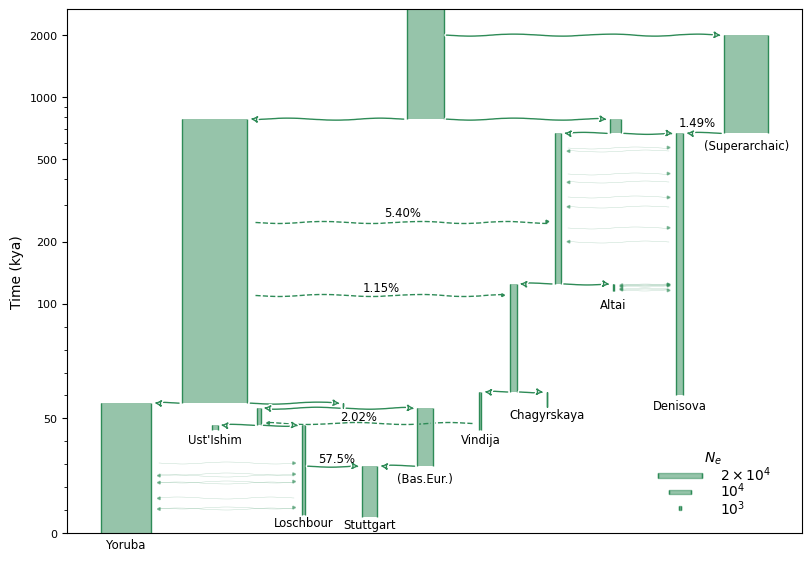

In [39]:
"""
Plot the full model
"""


def make_scale_bar(ax):
    transform = matplotlib.transforms.blended_transform_factory(
        ax.transData, ax.transAxes
    )
    ax_sb = ax.inset_axes((2e5, 0.05, 4e4, 1e-6), transform=transform)

    ax_sb.yaxis.set_major_locator(matplotlib.ticker.NullLocator())
    ax_sb.spines[["left", "right", "top"]].set_visible(False)
    ax_sb.xaxis.set_ticks_position("top")
    ax_sb.set_xticks(list(np.arange(0, 4e4, 2e3)), minor=True)
    ax_sb.set_xticks(list(np.arange(0, 5e4, 1e4)), labels=[0, None, r"$2\times 10^{4}$", None, r"$4\times 10^{4}$"])
    ax_sb.set_xlim(0, 4e4)
    ax_sb.set_xlabel("$N$")
    ax_sb.xaxis.set_label_position("bottom")


def plot_focal_model(ax):
    positions = {
        "Yoruba1": -1e4,
        "Stuttgart": 1.0e5,
        "Loschbour": 7e4,
        "UstIshim": 3e4,
        "Vindija": 1.5e5,
        "Chagyrskaya": 1.8e5, 
        "Altai": 2.1e5,
        "Denisova": 2.4e5,
        "Sup": 2.7e5,
        "MH": 3e4, 
        "WN": 1.65e5,
        "N": 1.85e5,
        "ND": 2.11e5,
        "Anc": 1.25e5,
        "OOA0": 8.8e4,
        "OOA1": 5e4,
        "BE": 1.25e5
    }

    fname = "models/main_models/bherer_full_edited.yaml"
    
    # map deme names to desired labels
    labels = {
        "Yoruba1": "Yoruba", 
        "UstIshim": "Ust'Ishim", 
        "Loschbour": "Loschbour", 
        "Stuttgart": "Stuttgart", 
        "Vindija": "Vindija", 
        "Chagyrskaya": "Chagyrskaya", 
        "Altai": "Altai", 
        "Denisova": "Denisova",
    }
    sample_times = {
        "Yoruba1": 0, 
        "UstIshim": 45000, 
        "Loschbour": 8000, 
        "Stuttgart": 7000, 
        "Vindija": 45000, 
        "Chagyrskaya": 55000, 
        "Altai": 115000, 
        "Denisova": 60000
    }
    graph = demes.load(fname)
    demesdraw.tubes(
        graph,
        ax=ax,
        colours=graph_color,
        labels=None,
        log_time=False,
        inf_ratio=0.25,
        positions=positions,
        num_lines_per_migration=4,
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_xticks([positions[x] for x in labels], [labels[x] for x in labels])
    ax.set_ylabel("Time (kya)")

    label_positions = {
        "Vindija": (positions["Vindija"], 3.9e4),
        "Chagyrskaya": (positions["Chagyrskaya"], 5e4),
        "Altai": (positions["Altai"], 9.8e4),
        "Denisova": (positions["Denisova"], 5.4e4),
        "Ust'Ishim":  (positions["UstIshim"], 3.9e4),
        "Loschbour":  (positions["Loschbour"], 3e3),
        "Stuttgart":  (positions["Stuttgart"], 2e3),
        "(Superarchaic)": (positions["Sup"], 5.6e5),
        "(Bas.Eur.)": (positions["BE"], 2.2e4),
    }
    for label, (x, y) in label_positions.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")

    # annotate pulses
    pulse_annotations = {
        "1.49%": (positions["Denisova"] + 8000, 7.2e5),
        "5.40%": (1.15e5, 2.65e5),
        "1.15%": (1.05e5, 1.15e5),
        "2.02%": (9.5e4, 4.9e4),
        "57.5%": ((positions["Stuttgart"] + positions["Loschbour"])/2, 3.1e4)
    }
    for label, (x, y) in pulse_annotations.items():
        ax.text(x, y, label, horizontalalignment="center", fontsize="small")

    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"], fontsize="small")

    ax.set_yscale("symlog", linthresh=1e5)
    ax.set_ylabel("Time (kya)")
    yticks = [0, 5e4, 1e5, 2e5, 5e5, 1e6, 2e6]
    ax.set_yticks(yticks, np.array(yticks).astype(np.int64) // 1000)
    yticks = np.concatenate(
        (np.arange(0, 100000, 10000), np.arange(200000, 1000000, 100000)))
    ax.set_yticks(yticks, minor=True)
    return


def plot_tube(ax, mid, y, width, height):
    vertices = [
        [mid - width / 2, y + height], 
        [mid - width / 2, y], 
        [mid + width / 2, y + height], 
        [mid + width / 2, y]
    ]
    codes = [np.uint8(1), np.uint8(2), np.uint8(1), np.uint8(2)]
    tube = matplotlib.path.Path(vertices, codes)
    path_patch = matplotlib.patches.PathPatch(
        tube, capstyle="butt", fill=False, color=graph_color, zorder=1
    )
    ax.add_patch(path_patch)
    ax.fill_betweenx(
        [y + height, y],
        [mid - width / 2, mid - width / 2],
        [mid + width / 2, mid + width / 2],
        facecolor=graph_color,
        edgecolor=graph_color,
        alpha=0.5,
        zorder=1,
    )
    return


def make_size_legend(ax, center):
    plot_tube(ax, center, 1e4, 1e3, 2e3)
    plot_tube(ax, center, 1.7e4, 1e4, 2e3)
    plot_tube(ax, center, 2.4e4, 2e4, 2e3)
    ax.text(center + 1.1e4, 3.1e4, "$N_e$")
    ax.text(center + 1.8e4, 8e3, "$10^3$")
    ax.text(center + 1.8e4, 1.6e4, "$10^4$")
    ax.text(center + 1.8e4, 2.3e4, r"$2\times 10^4$")
    return


fig, axs = plt.subplot_mosaic("A", figsize=(8, 5.5), layout="constrained")
plot_focal_model(axs["A"])
make_size_legend(axs["A"], 2.4e5)
plt.savefig("figures/full_model.pdf")

In [15]:
print(ll_tbl)

                                      model           ll
0                   bherer_amh_nea_no_pulse  -567.846098
1                  bherer_amh_nea_one_pulse  -498.726077
2                  bherer_amh_nea_two_pulse  -420.077055
3        bherer_amh_nea_two_pulse_free_time  -405.328349
4                   bherer_sup_den_no_pulse  -313.588698
5                            bherer_sup_den  -300.387859
6   bherer_sup_den_without_amh_nea_no_pulse  -591.700038
7            bherer_sup_den_without_amh_nea  -390.389234
8                  bherer_sup_den_free_time  -339.743235
9                  bherer_los_stu_isolation  -152.298345
10                 bherer_los_stu_migration   -87.692603
11                 bherer_los_stu_admixture   -78.632971
12                              bherer_full  -548.337455
13                bherer_full_fast_mutation -4261.489712
14                bherer_full_slow_mutation -9905.689944
15              bherer_full_without_sup_den  -574.693982
16                       bherer

In [16]:
"""
summarize likelihoods for supplementary tables
"""

# these are all BLRT tables
bher_amh_n_early = pandas.read_csv("models/blrt/bherer_amh_n_pulse.csv")["score"]
zhou_amh_n_early = pandas.read_csv("models/blrt/zhou_amh_n_pulse.csv")["score"]
bher_amh_n_late = pandas.read_csv("models/blrt/bherer_amh_wn_pulse.csv")["score"]
zhou_amh_n_late = pandas.read_csv("models/blrt/zhou_amh_wn_pulse.csv")["score"]
bher_sd = pandas.read_csv("models/blrt/bherer_sup_den_pulse.csv")["score"]
zhou_sd = pandas.read_csv("models/blrt/zhou_sup_den_pulse.csv")["score"]
bher_sd_no_amh_n = pandas.read_csv("models/blrt/bherer_sup_den_pulse_without_amh_nea.csv")["score"]
zhou_sd_no_amh_n = pandas.read_csv("models/blrt/zhou_sup_den_pulse_without_amh_nea.csv")["score"]
bher_be_admix = pandas.read_csv("models/blrt/bherer_los_stu_pulse.csv")["score"]
zhou_be_admix = pandas.read_csv("models/blrt/zhou_los_stu_pulse.csv")["score"]


def print_lrt(null_model, alt_model, blrt_tbl):
    blrt_tbl = np.array(blrt_tbl)
    blrt_tbl = blrt_tbl[blrt_tbl > 0]
    delta_ll = likelihoods[alt_model] - likelihoods[null_model]
    lr_stat = 2 * delta_ll
    print(" & ".join([str(x) for x in [
        int(likelihoods[null_model]),
        int(likelihoods[alt_model]),
        int(delta_ll),
        len(blrt_tbl),
        np.round(np.count_nonzero(blrt_tbl >= lr_stat) / len(blrt_tbl), 4)
    ]]) + r" \\")
    return

In [17]:
null_model = "bherer_amh_nea_no_pulse"
alt_model = "bherer_amh_nea_one_pulse"
blrt_tbl = bher_amh_n_early
print_lrt(null_model, alt_model, blrt_tbl)

-567 & -498 & 69 & 440 & 0.0 \\


In [18]:
null_model = "zhou_amh_nea_no_pulse"
alt_model = "zhou_amh_nea_one_pulse"
blrt_tbl = zhou_amh_n_early
print_lrt(null_model, alt_model, blrt_tbl)

-538 & -488 & 50 & 422 & 0.0 \\


In [19]:
null_model = "bherer_amh_nea_one_pulse"
alt_model = "bherer_amh_nea_two_pulse"
blrt_tbl = bher_amh_n_late
print_lrt(null_model, alt_model, blrt_tbl)

-498 & -420 & 78 & 400 & 0.0 \\


In [20]:
null_model = "zhou_amh_nea_one_pulse"
alt_model = "zhou_amh_nea_two_pulse"
blrt_tbl = zhou_amh_n_late
print_lrt(null_model, alt_model, blrt_tbl)

-488 & -426 & 62 & 393 & 0.0 \\


In [21]:
null_model = "bherer_sup_den_no_pulse"
alt_model = "bherer_sup_den"
blrt_tbl = bher_sd
print_lrt(null_model, alt_model, blrt_tbl)

-313 & -300 & 13 & 421 & 0.0214 \\


In [22]:
null_model = "zhou_sup_den_no_pulse"
alt_model = "zhou_sup_den"
blrt_tbl = zhou_sd
print_lrt(null_model, alt_model, blrt_tbl)

-313 & -307 & 5 & 407 & 0.0639 \\


In [23]:
null_model = "bherer_sup_den_without_amh_nea_no_pulse"
alt_model = "bherer_sup_den_without_amh_nea"
blrt_tbl = bher_sd_no_amh_n
print_lrt(null_model, alt_model, blrt_tbl)

-591 & -390 & 201 & 431 & 0.0 \\


In [24]:
null_model = "zhou_sup_den_without_amh_nea_no_pulse"
alt_model = "zhou_sup_den_without_amh_nea"
blrt_tbl = zhou_sd_no_amh_n
print_lrt(null_model, alt_model, blrt_tbl)

-584 & -411 & 172 & 441 & 0.0 \\


In [25]:
null_model = "bherer_los_stu_isolation"
alt_model = "bherer_los_stu_admixture"
blrt_tbl = bher_be_admix
print_lrt(null_model, alt_model, blrt_tbl)

-152 & -78 & 73 & 449 & 0.0 \\


In [26]:
null_model = "zhou_los_stu_isolation"
alt_model = "zhou_los_stu_admixture"
blrt_tbl = zhou_be_admix
print_lrt(null_model, alt_model, blrt_tbl)

-176 & -99 & 77 & 450 & 0.0 \\
